# Part 2 — Optimal K Selection (Elbow & Silhouette)

## 3. Optimal K Selection — Elbow & Silhouette

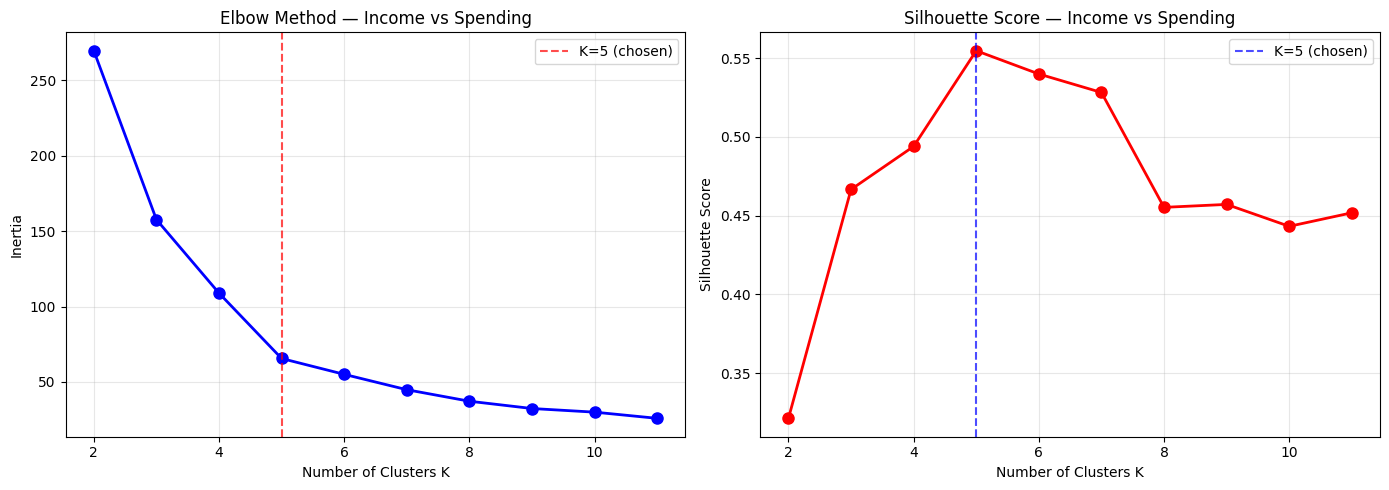

Best K by silhouette: 5
Max silhouette score: 0.5547


In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

scaler = StandardScaler()
X = scaler.fit_transform(df[['Income', 'Spending']])

K_range = range(2, 12)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 (chosen)')
axes[0].set_title('Elbow Method — Income vs Spending')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='blue', linestyle='--', alpha=0.7, label='K=5 (chosen)')
axes[1].set_title('Silhouette Score — Income vs Spending')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best K by silhouette: {K_range[silhouettes.index(max(silhouettes))]}")
print(f"Max silhouette score: {max(silhouettes):.4f}")

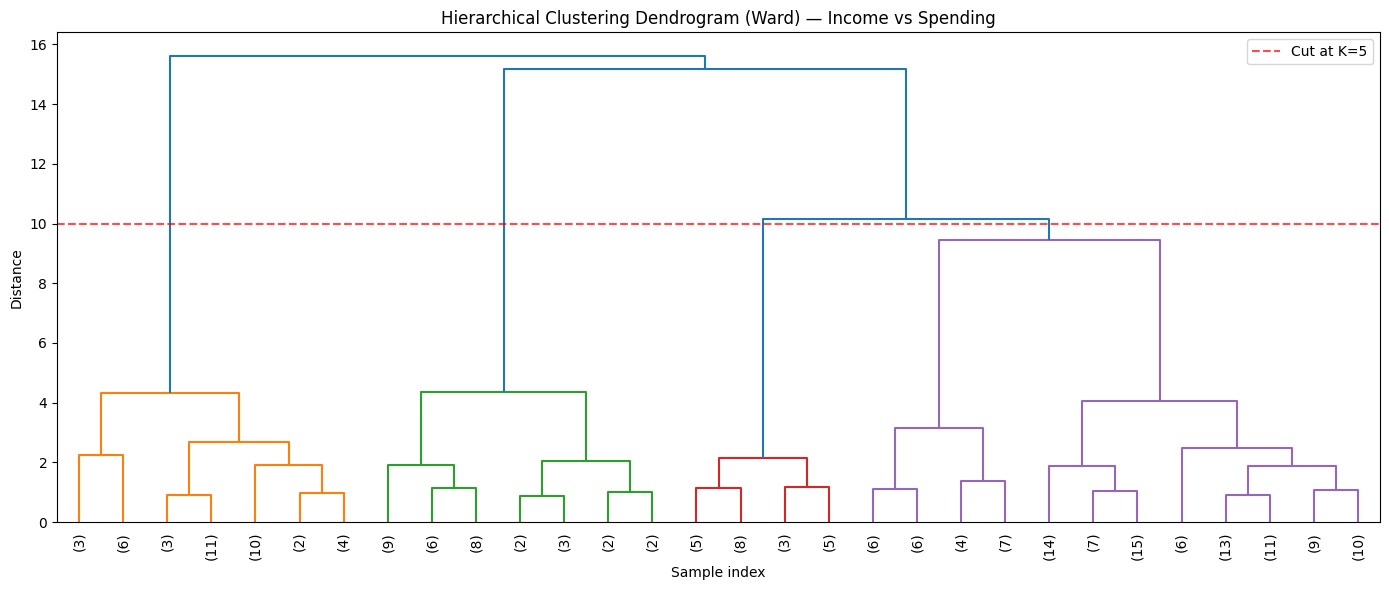

In [5]:
# Hierarchical dendrogram to confirm K=5
plt.figure(figsize=(14, 6))
linked = linkage(X, method='ward')
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,
           color_threshold=10)
plt.title('Hierarchical Clustering Dendrogram (Ward) — Income vs Spending')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Cut at K=5')
plt.legend()
plt.tight_layout()
plt.show()